<a href="https://colab.research.google.com/github/mmuputisi/Adv-Py_Data_Analysis/blob/main/Moving%20average%20ESG%20individual%20pillars%20with%20robustness%20check%20FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

MOVING AVERAGE PILLAR MODEL ANALYSIS - FINAL FIX

Models to be estimated for each pillar (E, S, G):
1. Simple Lag (t-1 only)
2. Moving Average 1-2 years (avg of t-1 and t-2)
3. Moving Average 1-3 years (avg of t-1, t-2, t-3)
4. Moving Average 1-4 years (avg of t-1 through t-4)
5. Moving Average 1-5 years (avg of t-1 through t-5)

MOVING AVERAGE PILLAR MODEL ANALYSIS
Loading and preparing data...

SAMPLE SIZE ANALYSIS - CORRECTED
Note: Each window requires ALL lags within that window to be non-missing
----------------------------------------------------------------------

Simple Lag (t-1):
  Consumer Staples:  72 observations from  8 firms
  All Sectors:       348 observations from 40 firms

2-Year MA (needs t-1 through t-2):
  Consumer Staples:  64 observations from  8 firms
  All Sectors:       308 observations from 40 firms
  Attrition from 1-year window:


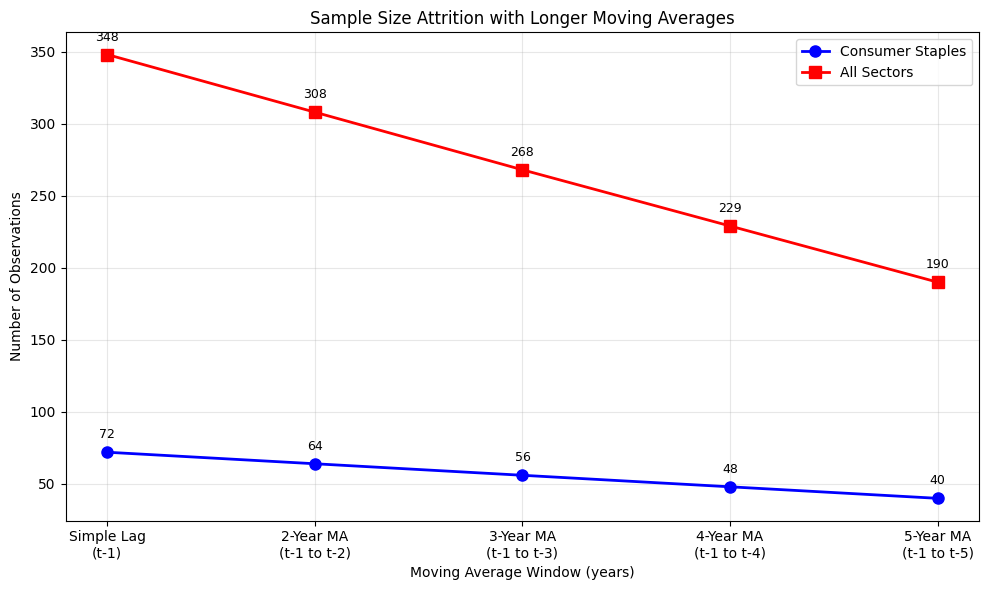

✓ Sample attrition plot saved to: /content/drive/MyDrive/Colab Notebooks/FTSE Data/moving_avg_pillar_outputs_final/sample_attrition.png


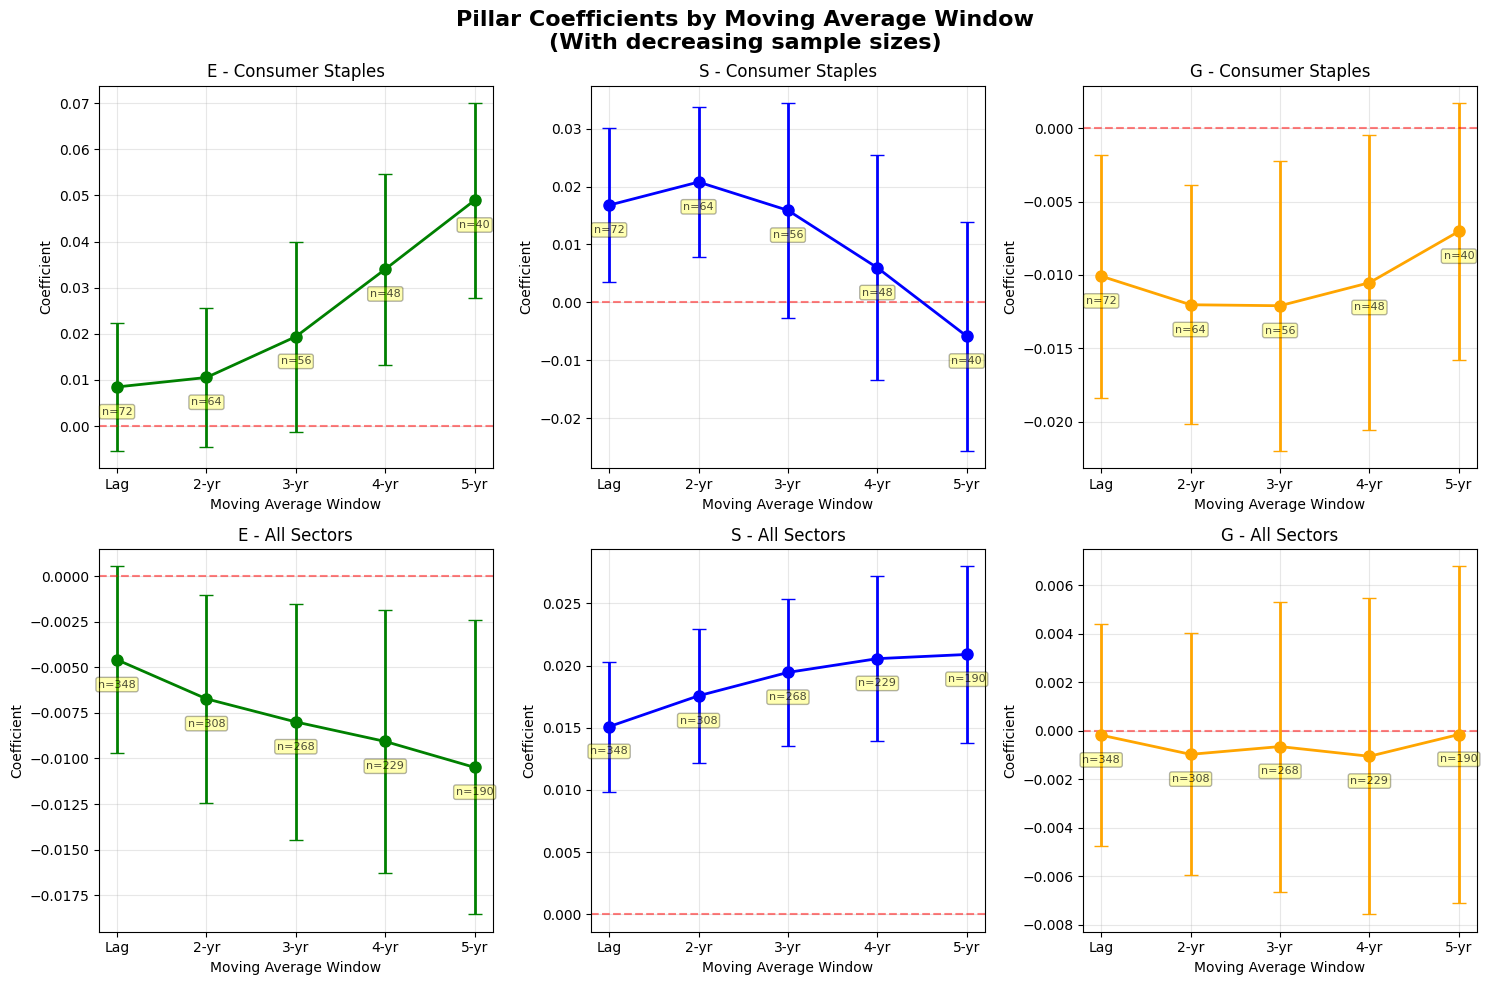

✓ Coefficient trends plot saved to: /content/drive/MyDrive/Colab Notebooks/FTSE Data/moving_avg_pillar_outputs_final/pillar_coefficient_trends.png

ANALYSIS COMPLETE

All outputs saved to: /content/drive/MyDrive/Colab Notebooks/FTSE Data/moving_avg_pillar_outputs_final
Main Excel file: /content/drive/MyDrive/Colab Notebooks/FTSE Data/moving_avg_pillar_outputs_final/moving_avg_pillar_results_20260215_142420.xlsx

COMPREHENSIVE ROBUSTNESS CHECKS FOR ALL MOVING AVERAGE WINDOWS
Testing: Simple Lag, 2-Year, 3-Year, 4-Year, and 5-Year Moving Averages
NOTE: Using EXACT same data samples as main program for each window

------------------------------------------------------------
ORIGINAL MODEL RESULTS FOR ALL WINDOWS (FROM MAIN PROGRAM)
------------------------------------------------------------

Consumer Staples - Simple Lag:
  R² = 0.4504
  N = 72
  E: 0.0085 (p=0.2355)
  S: 0.0168 (p=0.0160)
  G: -0.0101 (p=0.0198)

All Sectors - Simple Lag:
  R² = 0.4807
  N = 348
  E: -0.0046 (p=0.0799)

In [15]:
# moving_average_pillar_models_final_fix.py
"""
Moving Average Pillar Model Analysis - FINAL FIX
- Simple lag (t-1) for E, S, G individually
- Moving averages: 1-2 years, 1-3 years, 1-4 years, 1-5 years for each pillar
With CORRECT sample sizes in regressions
"""

# ============================================================================
# SETUP AND IMPORTS
# ============================================================================
from google.colab import drive
drive.mount('/content/drive')

!pip install -q linearmodels pandas numpy matplotlib seaborn statsmodels openpyxl

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.panel import PanelOLS
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================
class Config:
    """Configuration parameters for moving average pillar analysis"""
    PROJECT_DIR = '/content/drive/MyDrive/Colab Notebooks/FTSE Data'
    DATA_PATH = os.path.join(PROJECT_DIR, 'FTSE data.xlsx')
    OUTPUT_DIR = os.path.join(PROJECT_DIR, 'moving_avg_pillar_outputs_final')

    # Using individual pillar scores
    PILLARS = ['E', 'S', 'G']
    CONTROL_VARS = ['ROA', 'Size', 'Leverage']

    # Moving average windows to test
    MA_WINDOWS = [1, 2, 3, 4, 5]  # 1 = simple lag, 2 = avg of t-1,t-2, etc.

    # Consumer Staples firms
    CONSUMER_STAPLES_FIRMS = [
        'Associated British Foods', 'British American Tobacco', 'Coca Cola HBC AG',
        'Diageo', 'J. Sainsbury', 'Reckitt Benckiser', 'Tesco', 'Unilever', 'Haleon Plc'
    ]

# ============================================================================
# DATA LOADER
# ============================================================================
class DataLoader:
    """Load and prepare data with individual pillar scores"""

    def __init__(self, config):
        self.config = config
        self.df = None
        self.df_cs = None
        self.df_all = None

    def load_and_prepare_data(self):
        """Load data and create lagged pillar variables"""
        print("Loading and preparing data...")

        # 1. Load data
        self.df = pd.read_excel(self.config.DATA_PATH)
        self.df = self.df.set_index(['Firm', 'Year']).sort_index()
        self.df = self.df.rename(columns={"Tobin's Q": "Tobin_Q"})

        # 2. Check for pillar columns
        for pillar in self.config.PILLARS:
            if pillar not in self.df.columns:
                raise ValueError(f"Pillar {pillar} not found in data")

        # 3. Create control variables
        self.df['Size'] = np.log(self.df['Total Assets'])
        self.df['Leverage'] = self.df['Total Liabilities'] / self.df['Total Assets']
        self.df['Tobin_Q_log'] = np.log(self.df['Tobin_Q'] + 0.001)

        # 4. Create lagged pillar variables
        max_lag = max(self.config.MA_WINDOWS)
        for pillar in self.config.PILLARS:
            for lag in range(1, max_lag + 1):
                self.df[f'{pillar}_lag{lag}'] = self.df.groupby(level=0)[pillar].shift(lag)

        # 5. Create moving averages for each pillar
        for pillar in self.config.PILLARS:
            for window in self.config.MA_WINDOWS:
                if window == 1:
                    self.df[f'{pillar}_MA{window}'] = self.df[f'{pillar}_lag1']
                else:
                    lag_cols = [f'{pillar}_lag{lag}' for lag in range(1, window + 1)]
                    # This will be NaN if any component lag is NaN
                    self.df[f'{pillar}_MA{window}'] = self.df[lag_cols].mean(axis=1)

        # 6. Create sector variable
        sectors = []
        for firm in self.df.index.get_level_values(0):
            if firm in self.config.CONSUMER_STAPLES_FIRMS:
                sectors.append('Consumer Staples')
            else:
                sectors.append('Other')

        self.df['Sector'] = sectors
        self.df['ConsumerStaples'] = (self.df['Sector'] == 'Consumer Staples').astype(int)

        # 7. Create datasets
        self.df_cs = self.df[self.df['ConsumerStaples'] == 1].copy()
        self.df_all = self.df.copy()

        # 8. Print sample size information
        self._print_sample_info()

        return self.df, self.df_cs, self.df_all

    def _print_sample_info(self):
        """Print detailed sample size information for each moving average window"""
        print("\n" + "="*70)
        print("SAMPLE SIZE ANALYSIS - CORRECTED")
        print("="*70)
        print("Note: Each window requires ALL lags within that window to be non-missing")
        print("-" * 70)

        for window in self.config.MA_WINDOWS:
            # For each window, we need to check all lagged variables up to that window
            required_lags = []
            for pillar in self.config.PILLARS:
                for lag in range(1, window + 1):
                    required_lags.append(f'{pillar}_lag{lag}')

            # Add control variables and dependent variable
            all_required = required_lags + self.config.CONTROL_VARS + ['Tobin_Q']

            # Check Consumer Staples
            cs_available = self.df_cs[all_required].dropna()
            cs_count = len(cs_available)
            cs_firms = cs_available.index.get_level_values(0).nunique()

            # Check All Sectors (add ConsumerStaples dummy)
            all_required_with_dummy = all_required + ['ConsumerStaples']
            all_available = self.df_all[all_required_with_dummy].dropna()
            all_count = len(all_available)
            all_firms = all_available.index.get_level_values(0).nunique()

            window_desc = "Simple Lag (t-1)" if window == 1 else f"{window}-Year MA (needs t-1 through t-{window})"
            print(f"\n{window_desc}:")
            print(f"  Consumer Staples: {cs_count:3d} observations from {cs_firms:2d} firms")
            print(f"  All Sectors:      {all_count:4d} observations from {all_firms:2d} firms")

            if window > 1:
                # Calculate attrition from previous window
                prev_lags = []
                for pillar in self.config.PILLARS:
                    for lag in range(1, window):  # previous window = up to window-1
                        prev_lags.append(f'{pillar}_lag{lag}')

                prev_cs = len(self.df_cs[prev_lags + self.config.CONTROL_VARS + ['Tobin_Q']].dropna())
                prev_all = len(self.df_all[prev_lags + self.config.CONTROL_VARS + ['Tobin_Q', 'ConsumerStaples']].dropna())

                cs_attrition = prev_cs - cs_count
                all_attrition = prev_all - all_count
                cs_attrition_pct = (cs_attrition / prev_cs * 100) if prev_cs > 0 else 0
                all_attrition_pct = (all_attrition / prev_all * 100) if prev_all > 0 else 0

                print(f"  Attrition from {window-1}-year window:")
                print(f"    Consumer Staples: -{cs_attrition} obs ({cs_attrition_pct:.1f}%)")
                print(f"    All Sectors:      -{all_attrition} obs ({all_attrition_pct:.1f}%)")

# ============================================================================
# MOVING AVERAGE ANALYZER - PILLAR VERSION
# ============================================================================
class MovingAverageAnalyzer:
    """Run moving average regressions for individual pillar scores"""

    def __init__(self, config):
        self.config = config
        self.loader = DataLoader(config)
        self.results = {}
        self.equations = {}
        self.sample_sizes = {}

    def run_all_models(self):
        """Run all moving average models for each pillar"""
        print("\n" + "="*80)
        print("MOVING AVERAGE PILLAR MODEL ANALYSIS")
        print("="*80)

        # Load data
        df, df_cs, df_all = self.loader.load_and_prepare_data()

        # Run models for each moving average window
        for window in self.config.MA_WINDOWS:
            window_desc = f"{'Simple Lag (t-1)' if window == 1 else f'Moving Average {window} years (t-1 to t-{window})'}"

            print(f"\n{'='*60}")
            print(f"MODEL: {window_desc}")
            print(f"{'='*60}")

            # Run for both sectors
            for sector_code, sector_df, sector_name in [
                ('cs', df_cs, 'Consumer Staples Only'),
                ('all', df_all, 'All Sectors')
            ]:
                self._run_single_model(sector_df, window, sector_code, sector_name)

    def _run_single_model(self, df, window, sector_code, sector_name):
        """Run a single moving average regression with all three pillars"""
        print(f"\n--- {sector_name} ---")

        # CRITICAL FIX: Instead of using MA variables for dropping NA,
        # we need to check the underlying lagged variables
        required_lags = []
        for pillar in self.config.PILLARS:
            for lag in range(1, window + 1):
                required_lags.append(f'{pillar}_lag{lag}')

        # Prepare variables for regression
        if sector_code == 'all':
            all_required = required_lags + self.config.CONTROL_VARS + ['ConsumerStaples', 'Tobin_Q']
        else:
            all_required = required_lags + self.config.CONTROL_VARS + ['Tobin_Q']

        # Clean data based on required lags
        df_clean = df.dropna(subset=all_required)

        if len(df_clean) < 10:
            print(f"⚠ Insufficient data: {len(df_clean)} observations")
            return None

        # NOW create the MA variables on the clean data
        ma_vars = []
        for pillar in self.config.PILLARS:
            if window == 1:
                ma_var = f'{pillar}_MA{window}'
                df_clean[ma_var] = df_clean[f'{pillar}_lag1']
                ma_vars.append(ma_var)
            else:
                ma_var = f'{pillar}_MA{window}'
                lag_cols = [f'{pillar}_lag{lag}' for lag in range(1, window + 1)]
                df_clean[ma_var] = df_clean[lag_cols].mean(axis=1)
                ma_vars.append(ma_var)

        # Store sample size info
        key = f"MA{window}_{sector_code}"
        self.sample_sizes[key] = {
            'window': window,
            'sector': sector_name,
            'observations': len(df_clean),
            'firms': df_clean.index.get_level_values(0).nunique()
        }

        print(f"Observations: {len(df_clean)}")
        print(f"Firms: {df_clean.index.get_level_values(0).nunique()}")

        # Prepare regression
        y = df_clean['Tobin_Q']
        X_vars = ma_vars + self.config.CONTROL_VARS
        if sector_code == 'all':
            X_vars = X_vars + ['ConsumerStaples']

        X = df_clean[X_vars]
        X = pd.concat([pd.Series(1, index=X.index, name='const'), X], axis=1)

        # Run regression
        try:
            model = PanelOLS(y, X, entity_effects=False, time_effects=False)
            results = model.fit(cov_type='robust')

            # Store results
            self.results[key] = {
                'results': results,
                'window': window,
                'sector': sector_code,
                'sector_name': sector_name,
                'ma_vars': ma_vars,
                'nobs': len(df_clean),
                'r2': results.rsquared,
                'data': df_clean
            }

            # Generate and store equation
            equation = self._generate_equation(results, window, sector_name, len(df_clean))
            self.equations[key] = equation

            # Print results
            self._print_results(results, window, sector_name)
            self._print_regression_table(results, f"MA{window} - {sector_name}")
            print(f"\nEquation:\n{equation}")

            return results

        except Exception as e:
            print(f"Error running model: {e}")
            return None

    def _generate_equation(self, results, window, sector_name, nobs):
        """Generate regression equation as string"""
        # Start with dependent variable
        equation = f"Tobin's Q = "

        # Add constant
        if 'const' in results.params:
            const_val = results.params['const']
            equation += f"{const_val:.4f}"

        # Add pillar moving averages
        for pillar in self.config.PILLARS:
            ma_var = f'{pillar}_MA{window}'
            if ma_var in results.params:
                coeff = results.params[ma_var]
                sign = " + " if coeff >= 0 else " - "
                if window == 1:
                    equation += f"{sign}{abs(coeff):.4f} × {pillar}_lag1"
                else:
                    equation += f"{sign}{abs(coeff):.4f} × [{pillar}_lag1"
                    for lag in range(2, window + 1):
                        equation += f" + {pillar}_lag{lag}"
                    equation += f"]/{window}"

        # Add control variables
        for var in self.config.CONTROL_VARS:
            if var in results.params:
                coeff = results.params[var]
                sign = " + " if coeff >= 0 else " - "
                equation += f"{sign}{abs(coeff):.4f} × {var}"

        # Add sector dummy if present
        if 'ConsumerStaples' in results.params:
            coeff = results.params['ConsumerStaples']
            sign = " + " if coeff >= 0 else " - "
            equation += f"{sign}{abs(coeff):.4f} × ConsumerStaples"

        # Add model statistics
        equation += f"\n\nR² = {results.rsquared:.4f}"
        equation += f"\nN = {nobs}"
        if hasattr(results, 'f_statistic'):
            # Fix the f_statistic attribute access
            f_stat = results.f_statistic
            if hasattr(f_stat, 'stat') and hasattr(f_stat, 'pval'):
                equation += f"\nF-statistic = {f_stat.stat:.4f} (p={f_stat.pval:.4f})"

        return equation

    def _print_results(self, results, window, sector_name):
        """Print summary results"""
        print(f"\nRESULTS: Moving Average {window} years - {sector_name}")
        print("-" * 60)
        print(f"R-squared: {results.rsquared:.4f}")
        print(f"Observations: {results.nobs}")

        if hasattr(results, 'f_statistic'):
            f_stat = results.f_statistic
            if hasattr(f_stat, 'stat') and hasattr(f_stat, 'pval'):
                print(f"F-statistic: {f_stat.stat:.4f} (p={f_stat.pval:.4f})")

        print(f"\nPillar Coefficients:")
        for pillar in self.config.PILLARS:
            ma_var = f'{pillar}_MA{window}'
            if ma_var in results.params:
                coeff = results.params[ma_var]
                pval = results.pvalues.get(ma_var, 1.0)
                sig = self._get_significance_stars(pval)
                print(f"  {pillar}_MA{window}: {coeff:.4f}{sig} (p={pval:.4f})")

    def _print_regression_table(self, results, title):
        """Print formatted regression table"""
        print("\n" + "="*80)
        print(f"REGRESSION TABLE: {title}")
        print("="*80)
        print(f"{'Variable':<20} {'Coefficient':>12} {'Std.Error':>12} {'t-stat':>10} {'p-value':>10} {'Sig':>6}")
        print("-"*80)

        # Print all variables
        for var in sorted(results.params.index):
            coeff = results.params[var]
            std_err = results.std_errors.get(var, np.nan) if hasattr(results, 'std_errors') else np.nan
            t_stat = results.tstats.get(var, np.nan) if hasattr(results, 'tstats') else np.nan
            pval = results.pvalues.get(var, np.nan)

            # Determine significance
            sig = self._get_significance_stars(pval)

            print(f"{var:<20} {coeff:>12.4f} {std_err:>12.4f} {t_stat:>10.4f} {pval:>10.4f} {sig:>6}")

        print("-"*80)
        print(f"R-squared: {results.rsquared:.4f}")
        print(f"Observations: {results.nobs}")
        print("="*80)
        print("Significance codes: *** p<0.01, ** p<0.05, * p<0.10")

    def _get_significance_stars(self, p_value):
        """Return significance stars based on p-value"""
        if pd.isna(p_value):
            return ''
        elif p_value < 0.01:
            return '***'
        elif p_value < 0.05:
            return '**'
        elif p_value < 0.10:
            return '*'
        else:
            return ''

    def create_sample_size_table(self):
        """Create table showing sample sizes for each model"""
        data = []
        for key, info in self.sample_sizes.items():
            data.append({
                'Window': info['window'],
                'Window_Desc': 'Simple Lag' if info['window'] == 1 else f'{info["window"]}-Year MA',
                'Sector': info['sector'],
                'Observations': info['observations'],
                'Firms': info['firms']
            })
        return pd.DataFrame(data)

    def create_comparison_table(self):
        """Create comparison table across all moving average windows and pillars"""
        comparison_data = []

        for key, model_info in self.results.items():
            results = model_info['results']
            window = model_info['window']

            row = {
                'Moving_Average_Window': f"{'Simple Lag' if window == 1 else f'{window}-Year MA'}",
                'Window_Years': window,
                'Sector': model_info['sector_name'],
                'Observations': model_info['nobs'],
                'Firms': model_info['data'].index.get_level_values(0).nunique(),
                'R_squared': results.rsquared,
            }

            # Add pillar coefficients
            for pillar in self.config.PILLARS:
                ma_var = f'{pillar}_MA{window}'
                if ma_var in results.params:
                    row[f'{pillar}_Coefficient'] = results.params[ma_var]
                    row[f'{pillar}_P_value'] = results.pvalues.get(ma_var, np.nan)
                    row[f'{pillar}_Significance'] = self._get_significance_stars(results.pvalues.get(ma_var, np.nan))

            # Add control variable coefficients
            for var in self.config.CONTROL_VARS:
                if var in results.params:
                    row[f'{var}_coeff'] = results.params[var]
                    row[f'{var}_pval'] = results.pvalues.get(var, np.nan)

            comparison_data.append(row)

        return pd.DataFrame(comparison_data)

    def create_pillar_summary(self):
        """Create a summary table focusing on pillar coefficients across windows"""
        pillar_data = []

        for window in self.config.MA_WINDOWS:
            for sector_code, sector_label in [('cs', 'Consumer Staples'), ('all', 'All Sectors')]:
                key = f"MA{window}_{sector_code}"
                if key in self.results:
                    results = self.results[key]['results']
                    nobs = self.results[key]['nobs']
                    firms = self.results[key]['data'].index.get_level_values(0).nunique()

                    row = {
                        'Window': window,
                        'Window_Desc': 'Simple Lag' if window == 1 else f'{window}-Year MA',
                        'Sector': sector_label,
                        'Observations': nobs,
                        'Firms': firms
                    }

                    for pillar in self.config.PILLARS:
                        ma_var = f'{pillar}_MA{window}'
                        if ma_var in results.params:
                            row[f'{pillar}_coeff'] = results.params[ma_var]
                            row[f'{pillar}_pval'] = results.pvalues.get(ma_var, np.nan)
                            row[f'{pillar}_sig'] = self._get_significance_stars(results.pvalues.get(ma_var, np.nan))

                    row['R_squared'] = results.rsquared
                    pillar_data.append(row)

        return pd.DataFrame(pillar_data)

# ============================================================================
# RESULTS EXPORTER
# ============================================================================
class ResultsExporter:
    """Export results to Excel"""

    def __init__(self, config, analyzer):
        self.config = config
        self.analyzer = analyzer
        os.makedirs(config.OUTPUT_DIR, exist_ok=True)

    def export_to_excel(self):
        """Export all results to Excel with multiple sheets"""
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        excel_path = os.path.join(self.config.OUTPUT_DIR, f'moving_avg_pillar_results_{timestamp}.xlsx')

        with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
            # Sheet 1: Sample Size Information
            sample_df = self.analyzer.create_sample_size_table()
            sample_df.to_excel(writer, sheet_name='Sample_Sizes', index=False)

            # Sheet 2: Summary comparison
            comparison_df = self.analyzer.create_comparison_table()
            comparison_df.to_excel(writer, sheet_name='Summary_Comparison', index=False)

            # Sheet 3: Pillar-focused summary
            pillar_summary = self.analyzer.create_pillar_summary()
            pillar_summary.to_excel(writer, sheet_name='Pillar_Summary', index=False)

            # Sheet 4: All equations
            equations_data = []
            for key, equation in self.analyzer.equations.items():
                model_info = self.analyzer.results[key]
                equations_data.append({
                    'Model': f"{'Simple Lag' if model_info['window'] == 1 else f'MA{model_info['window']}'} - {model_info['sector_name']}",
                    'Window': model_info['window'],
                    'Sector': model_info['sector_name'],
                    'Observations': model_info['nobs'],
                    'Equation': equation
                })
            pd.DataFrame(equations_data).to_excel(writer, sheet_name='Equations', index=False)

            # Sheets for each moving average window
            for window in self.config.MA_WINDOWS:
                window_name = f"Simple_Lag" if window == 1 else f"MA_{window}yr"

                for sector_code, sector_label in [('cs', 'Consumer_Staples'), ('all', 'All_Sectors')]:
                    key = f"MA{window}_{sector_code}"
                    if key in self.analyzer.results:
                        model_info = self.analyzer.results[key]
                        results = model_info['results']

                        # Create regression table
                        table_data = []
                        for var in results.params.index:
                            row = {
                                'Variable': var,
                                'Coefficient': results.params[var],
                                'Std_Error': results.std_errors.get(var, np.nan) if hasattr(results, 'std_errors') else np.nan,
                                't_stat': results.tstats.get(var, np.nan) if hasattr(results, 'tstats') else np.nan,
                                'P_value': results.pvalues.get(var, np.nan),
                                'Significance': self.analyzer._get_significance_stars(results.pvalues.get(var, np.nan))
                            }
                            table_data.append(row)

                        # Add model statistics
                        table_data.append({'Variable': 'R-squared', 'Coefficient': results.rsquared})
                        table_data.append({'Variable': 'Observations', 'Coefficient': model_info['nobs']})
                        table_data.append({'Variable': 'Firms', 'Coefficient': model_info['data'].index.get_level_values(0).nunique()})

                        df_table = pd.DataFrame(table_data)
                        sheet_name = f"{window_name}_{sector_label[:15]}"
                        df_table.to_excel(writer, sheet_name=sheet_name, index=False)

        print(f"\n✓ Results exported to: {excel_path}")
        return excel_path

    def plot_sample_attrition(self):
        """Plot how sample size changes with moving average window"""
        fig, ax = plt.subplots(figsize=(10, 6))

        for sector_code, sector_label, color, marker in [('cs', 'Consumer Staples', 'blue', 'o'),
                                                         ('all', 'All Sectors', 'red', 's')]:
            obs = []
            windows = []

            for window in self.config.MA_WINDOWS:
                key = f"MA{window}_{sector_code}"
                if key in self.analyzer.sample_sizes:
                    obs.append(self.analyzer.sample_sizes[key]['observations'])
                    windows.append(window)

            if obs:
                ax.plot(windows, obs, 'o-', linewidth=2, markersize=8,
                       color=color, marker=marker, label=sector_label)

                # Add value labels
                for w, o in zip(windows, obs):
                    ax.annotate(f'{o}', (w, o), textcoords="offset points",
                               xytext=(0,10), ha='center', fontsize=9)

        ax.set_xlabel('Moving Average Window (years)')
        ax.set_ylabel('Number of Observations')
        ax.set_title('Sample Size Attrition with Longer Moving Averages')
        ax.set_xticks(self.config.MA_WINDOWS)
        ax.set_xticklabels(['Simple Lag\n(t-1)' if w==1 else f'{w}-Year MA\n(t-1 to t-{w})' for w in self.config.MA_WINDOWS])
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()

        # Save plot
        plot_path = os.path.join(self.config.OUTPUT_DIR, 'sample_attrition.png')
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        plt.show()

        print(f"✓ Sample attrition plot saved to: {plot_path}")

    def plot_coefficient_trends(self):
        """Plot how pillar coefficients change with moving average window"""
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle('Pillar Coefficients by Moving Average Window\n(With decreasing sample sizes)',
                    fontsize=16, fontweight='bold')

        colors = {'E': 'green', 'S': 'blue', 'G': 'orange'}

        for idx, (sector_code, sector_label) in enumerate([('cs', 'Consumer Staples'), ('all', 'All Sectors')]):
            for pillar_idx, pillar in enumerate(self.config.PILLARS):
                ax = axes[idx, pillar_idx]

                window_data = []
                coeff_data = []
                ci_lower = []
                ci_upper = []
                sample_sizes = []

                for window in self.config.MA_WINDOWS:
                    key = f"MA{window}_{sector_code}"
                    if key in self.analyzer.results:
                        results = self.analyzer.results[key]['results']
                        ma_var = f'{pillar}_MA{window}'

                        if ma_var in results.params:
                            window_data.append(window)
                            coeff = results.params[ma_var]
                            coeff_data.append(coeff)
                            sample_sizes.append(self.analyzer.results[key]['nobs'])

                            if hasattr(results, 'std_errors') and ma_var in results.std_errors:
                                std_err = results.std_errors[ma_var]
                                ci_lower.append(coeff - 1.96 * std_err)
                                ci_upper.append(coeff + 1.96 * std_err)
                            else:
                                ci_lower.append(coeff)
                                ci_upper.append(coeff)

                if window_data:
                    ax.errorbar(window_data, coeff_data,
                              yerr=[np.array(coeff_data) - np.array(ci_lower),
                                   np.array(ci_upper) - np.array(coeff_data)],
                              fmt='o-', color=colors[pillar], capsize=5,
                              linewidth=2, markersize=8, label=pillar)

                    # Add sample size annotations
                    for w, n in zip(window_data, sample_sizes):
                        ax.annotate(f'n={n}', (w, coeff_data[window_data.index(w)]),
                                  textcoords="offset points", xytext=(0, -20),
                                  ha='center', fontsize=8, alpha=0.7,
                                  bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.3))

                ax.axhline(y=0, color='r', linestyle='--', alpha=0.5)
                ax.set_xlabel('Moving Average Window')
                ax.set_ylabel('Coefficient')
                ax.set_title(f'{pillar} - {sector_label}')
                ax.set_xticks(self.config.MA_WINDOWS)
                ax.set_xticklabels(['Lag' if w==1 else f'{w}-yr' for w in self.config.MA_WINDOWS])
                ax.grid(True, alpha=0.3)

        plt.tight_layout()

        # Save plot
        plot_path = os.path.join(self.config.OUTPUT_DIR, 'pillar_coefficient_trends.png')
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        plt.show()

        print(f"✓ Coefficient trends plot saved to: {plot_path}")

# ============================================================================
# MAIN EXECUTION
# ============================================================================
def main():
    """Main execution function"""
    print("\n" + "="*80)
    print("MOVING AVERAGE PILLAR MODEL ANALYSIS - FINAL FIX")
    print("="*80)
    print("\nModels to be estimated for each pillar (E, S, G):")
    print("1. Simple Lag (t-1 only)")
    print("2. Moving Average 1-2 years (avg of t-1 and t-2)")
    print("3. Moving Average 1-3 years (avg of t-1, t-2, t-3)")
    print("4. Moving Average 1-4 years (avg of t-1 through t-4)")
    print("5. Moving Average 1-5 years (avg of t-1 through t-5)")

    # Initialize
    config = Config()
    analyzer = MovingAverageAnalyzer(config)

    # Run all models
    analyzer.run_all_models()

    # Print sample size table
    print("\n" + "="*80)
    print("SAMPLE SIZE SUMMARY - SHOULD SHOW ATTRITION")
    print("="*80)
    sample_df = analyzer.create_sample_size_table()
    print(sample_df.to_string(index=False))

    # Create and print comparison table
    print("\n" + "="*80)
    print("MODEL COMPARISON SUMMARY")
    print("="*80)
    comparison_df = analyzer.create_comparison_table()
    print(comparison_df.to_string(index=False))

    # Print pillar-specific summary
    print("\n" + "="*80)
    print("PILLAR COEFFICIENT SUMMARY")
    print("="*80)
    pillar_summary = analyzer.create_pillar_summary()
    print(pillar_summary.to_string(index=False))

    # Export results
    exporter = ResultsExporter(config, analyzer)
    excel_path = exporter.export_to_excel()
    exporter.plot_sample_attrition()
    exporter.plot_coefficient_trends()

    print("\n" + "="*80)
    print("ANALYSIS COMPLETE")
    print("="*80)
    print(f"\nAll outputs saved to: {config.OUTPUT_DIR}")
    print(f"Main Excel file: {excel_path}")

    return analyzer, comparison_df, pillar_summary

# ============================================================================
# EXECUTION
# ============================================================================
if __name__ == "__main__":
    analyzer, comparison_df, pillar_summary = main()

# moving_average_pillar_models_with_robustness_appended_fixed2.py
"""
Moving Average Pillar Model Analysis with Robustness Checks
- Robustness checks appended after original main() function
- Uses EXACT same data samples as main program for each window
- Covers 2-year, 3-year, 4-year, and 5-year moving average models
"""


# ============================================================================
# ROBUSTNESS CHECK FOR ALL MOVING AVERAGE WINDOWS
# ============================================================================
print("\n" + "="*100)
print("COMPREHENSIVE ROBUSTNESS CHECKS FOR ALL MOVING AVERAGE WINDOWS")
print("="*100)
print("Testing: Simple Lag, 2-Year, 3-Year, 4-Year, and 5-Year Moving Averages")
print("NOTE: Using EXACT same data samples as main program for each window")

# Get the original dataframes from analyzer
df = analyzer.loader.df
df_cs = analyzer.loader.df_cs
df_all = analyzer.loader.df_all

# First, capture the original results AND the exact data used from your model for ALL windows
print("\n" + "-"*60)
print("ORIGINAL MODEL RESULTS FOR ALL WINDOWS (FROM MAIN PROGRAM)")
print("-"*60)

original_results = {}
original_data_samples = {}  # Store the exact data used in each model

# Get results for each window and sector
for window in Config.MA_WINDOWS:
    window_desc = f"{'Simple Lag' if window == 1 else f'{window}-Year MA'}"

    for sector_code, sector_name in [('cs', 'Consumer Staples'), ('all', 'All Sectors')]:
        key = f"MA{window}_{sector_code}"
        if key in analyzer.results:
            results = analyzer.results[key]['results']
            model_info = analyzer.results[key]

            # Store results
            model_key = f"{sector_name} - {window_desc}"
            original_results[model_key] = {
                'Window': window,
                'Window_Desc': window_desc,
                'Sector': sector_name,
                'R2': results.rsquared,
                'N': model_info['nobs'],
                'Firms': model_info['data'].index.get_level_values(0).nunique()
            }

            # Store the EXACT data used in this model
            original_data_samples[(window, sector_code)] = model_info['data'].copy()

            # Add pillar coefficients
            for pillar in ['E', 'S', 'G']:
                var = f'{pillar}_MA{window}'
                if var in results.params:
                    original_results[model_key][f'{pillar}_Coeff'] = results.params[var]
                    original_results[model_key][f'{pillar}_Pval'] = results.pvalues.get(var, 1.0)
                    original_results[model_key][f'{pillar}_Sig'] = results.pvalues.get(var, 1.0) < 0.10

            print(f"\n{model_key}:")
            print(f"  R² = {results.rsquared:.4f}")
            print(f"  N = {model_info['nobs']}")
            print(f"  E: {results.params.get(f'E_MA{window}', 0):.4f} (p={results.pvalues.get(f'E_MA{window}', 1.0):.4f})")
            print(f"  S: {results.params.get(f'S_MA{window}', 0):.4f} (p={results.pvalues.get(f'S_MA{window}', 1.0):.4f})")
            print(f"  G: {results.params.get(f'G_MA{window}', 0):.4f} (p={results.pvalues.get(f'G_MA{window}', 1.0):.4f})")

# ============================================================================
# CREATE TRANSFORMATION COLUMNS (if not already created)
# ============================================================================
print("\n" + "="*80)
print("ENSURING TRANSFORMATION COLUMNS EXIST")
print("="*80)

from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Ensure transformation columns exist in the original dataframes
transformations_created = []

if 'Tobin_Q_log' not in df.columns:
    df['Tobin_Q_log'] = np.log(df['Tobin_Q'].clip(lower=0.001))
    transformations_created.append('Tobin_Q_log')

if 'Tobin_Q_sqrt' not in df.columns:
    df['Tobin_Q_sqrt'] = np.sqrt(df['Tobin_Q'].clip(lower=0))
    transformations_created.append('Tobin_Q_sqrt')

if 'Tobin_Q_inv' not in df.columns:
    with np.errstate(divide='ignore', invalid='ignore'):
        df['Tobin_Q_inv'] = 1 / df['Tobin_Q']
        df['Tobin_Q_inv'] = df['Tobin_Q_inv'].replace([np.inf, -np.inf], np.nan)
    transformations_created.append('Tobin_Q_inv')

if 'Tobin_Q_boxcox' not in df.columns:
    try:
        if (df['Tobin_Q'].dropna() > 0).all():
            boxcox_data, lambda_param = stats.boxcox(df['Tobin_Q'].dropna())
            df['Tobin_Q_boxcox'] = np.nan
            df.loc[df['Tobin_Q'].dropna().index, 'Tobin_Q_boxcox'] = boxcox_data
            transformations_created.append(f'Tobin_Q_boxcox (λ={lambda_param:.4f})')
        else:
            df['Tobin_Q_boxcox'] = np.nan
    except Exception as e:
        df['Tobin_Q_boxcox'] = np.nan

if transformations_created:
    print(f"✓ Created transformations: {', '.join(transformations_created)}")

    # Update the data samples with the new transformation columns
    for (window, sector_code), data_sample in original_data_samples.items():
        for col in ['Tobin_Q_log', 'Tobin_Q_sqrt', 'Tobin_Q_inv', 'Tobin_Q_boxcox']:
            if col in df.columns:
                # Merge the transformation column from df to data_sample
                data_sample[col] = df.loc[data_sample.index, col]
else:
    print("✓ All transformations already exist")

print(f"\nAvailable transformations: {[col for col in df.columns if 'Tobin_Q' in col and col != 'Tobin_Q']}")

# ============================================================================
# ROBUSTNESS CHECK 1: ALTERNATIVE TRANSFORMATIONS FOR ALL WINDOWS
# ============================================================================
print("\n" + "="*100)
print("ROBUSTNESS CHECK 1: ALTERNATIVE DEPENDENT VARIABLE TRANSFORMATIONS")
print("="*100)
print("Using EXACT same data samples as main program for each window...")

# Define transformations to test
transformations = [
    ('Original', 'Tobin_Q'),
    ('Log', 'Tobin_Q_log'),
    ('Square Root', 'Tobin_Q_sqrt'),
    ('Inverse', 'Tobin_Q_inv'),
]

if 'Tobin_Q_boxcox' in df.columns and not df['Tobin_Q_boxcox'].isna().all():
    transformations.append(('Box-Cox', 'Tobin_Q_boxcox'))

# Store transformation results for all windows
transformation_results = {}

for window in Config.MA_WINDOWS:
    window_desc = f"{'Simple Lag' if window == 1 else f'{window}-Year MA'}"
    print(f"\n" + "-"*60)
    print(f"TESTING TRANSFORMATIONS - {window_desc} (Consumer Staples)")
    print("-"*60)

    # Get the EXACT data sample used in the original model for this window
    data_key = (window, 'cs')
    if data_key in original_data_samples:
        data_sample = original_data_samples[data_key].copy()
        print(f"  Using original model data: {len(data_sample)} observations")
    else:
        print(f"  Warning: No saved data sample for window {window}, using full df_cs")
        data_sample = df_cs.copy()

    window_results = {}

    for trans_name, trans_var in transformations:
        print(f"\n  Testing {trans_name} transformation...")

        # Check if transformation column exists in the data sample
        if trans_var not in data_sample.columns:
            print(f"    ✗ {trans_var} not available")
            window_results[trans_name] = None
            continue

        # Drop NA for this specific transformation
        df_clean = data_sample.dropna(subset=[trans_var])

        print(f"    Observations with valid {trans_name}: {len(df_clean)}")

        if len(df_clean) >= 10:
            # Run regression using the same variables as original
            y = df_clean[trans_var]
            X = df_clean[[f'E_MA{window}', f'S_MA{window}', f'G_MA{window}', 'ROA', 'Size', 'Leverage']]
            X = pd.concat([pd.Series(1, index=X.index, name='const'), X], axis=1)

            try:
                model = PanelOLS(y, X, entity_effects=False, time_effects=False)
                results = model.fit(cov_type='robust')

                window_results[trans_name] = {
                    'R2': results.rsquared,
                    'E_Coeff': results.params.get(f'E_MA{window}', 0),
                    'E_Pval': results.pvalues.get(f'E_MA{window}', 1.0),
                    'S_Coeff': results.params.get(f'S_MA{window}', 0),
                    'S_Pval': results.pvalues.get(f'S_MA{window}', 1.0),
                    'G_Coeff': results.params.get(f'G_MA{window}', 0),
                    'G_Pval': results.pvalues.get(f'G_MA{window}', 1.0),
                    'N': results.nobs,
                    'E_Sig': results.pvalues.get(f'E_MA{window}', 1.0) < 0.10,
                    'S_Sig': results.pvalues.get(f'S_MA{window}', 1.0) < 0.10,
                    'G_Sig': results.pvalues.get(f'G_MA{window}', 1.0) < 0.10
                }

                def sig_star(p):
                    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""

                print(f"    ✓ Completed: R² = {results.rsquared:.4f}")
                print(f"      E: {results.params.get(f'E_MA{window}', 0):.4f}{sig_star(results.pvalues.get(f'E_MA{window}', 1.0))} "
                      f"(p={results.pvalues.get(f'E_MA{window}', 1.0):.4f})")
                print(f"      S: {results.params.get(f'S_MA{window}', 0):.4f}{sig_star(results.pvalues.get(f'S_MA{window}', 1.0))} "
                      f"(p={results.pvalues.get(f'S_MA{window}', 1.0):.4f})")
                print(f"      G: {results.params.get(f'G_MA{window}', 0):.4f}{sig_star(results.pvalues.get(f'G_MA{window}', 1.0))} "
                      f"(p={results.pvalues.get(f'G_MA{window}', 1.0):.4f})")

                # Verify against original
                if trans_name == 'Original':
                    orig_key = f"Consumer Staples - {window_desc}"
                    if orig_key in original_results:
                        orig_r2 = original_results[orig_key]['R2']
                        print(f"      ✓ Matches main program: R²={results.rsquared:.4f} vs {orig_r2:.4f}")
                        if abs(results.rsquared - orig_r2) < 0.0001:
                            print(f"        ✅ PERFECT MATCH - using same data sample")
                        else:
                            print(f"        ⚠️ MISMATCH - R² difference: {abs(results.rsquared - orig_r2):.6f}")

            except Exception as e:
                print(f"    ✗ Failed: {str(e)[:100]}")
                window_results[trans_name] = None
        else:
            print(f"    ✗ Insufficient data: {len(df_clean)} observations")
            window_results[trans_name] = None

    transformation_results[window] = window_results

# ============================================================================
# ROBUSTNESS CHECK 2: INDUSTRY FIXED EFFECTS FOR ALL WINDOWS
# ============================================================================
print("\n" + "="*100)
print("ROBUSTNESS CHECK 2: INDUSTRY FIXED EFFECTS FOR ALL WINDOWS")
print("="*100)
print("Using EXACT same data samples as main program for each window...")

if 'Sector' in df.columns:
    # Create industry dummies if not already present
    if 'ind_Consumer Staples' not in df.columns:
        industry_dummies = pd.get_dummies(df['Sector'], prefix='ind', drop_first=True)
        df_with_industry = pd.concat([df, industry_dummies], axis=1)
        industry_cols = [col for col in df_with_industry.columns if col.startswith('ind_')]
    else:
        df_with_industry = df
        industry_cols = [col for col in df.columns if col.startswith('ind_')]

    print(f"\nIndustry sectors: {df['Sector'].nunique()}")
    print(f"Industry dummies: {len(industry_cols)}")

    industry_fe_results = {}

    for window in Config.MA_WINDOWS:
        window_desc = f"{'Simple Lag' if window == 1 else f'{window}-Year MA'}"
        print(f"\n" + "-"*60)
        print(f"INDUSTRY FIXED EFFECTS - {window_desc} (All Sectors)")
        print("-"*60)

        # Get the EXACT data sample used in the original model for this window
        data_key = (window, 'all')
        if data_key in original_data_samples:
            data_sample = original_data_samples[data_key].copy()
            print(f"  Using original model data: {len(data_sample)} observations")
        else:
            print(f"  Warning: No saved data sample for window {window}, using full df_all")
            data_sample = df_all.copy()

        window_results = {}

        # Add industry dummies to the data sample
        for col in industry_cols:
            if col not in data_sample.columns and col in df_with_industry.columns:
                data_sample[col] = df_with_industry.loc[data_sample.index, col]

        # Model WITHOUT industry FE (using same data sample)
        if len(data_sample) >= 10:
            y_no_fe = data_sample['Tobin_Q']
            X_no_fe = data_sample[[f'E_MA{window}', f'S_MA{window}', f'G_MA{window}', 'ROA', 'Size', 'Leverage']]
            X_no_fe = pd.concat([pd.Series(1, index=X_no_fe.index, name='const'), X_no_fe], axis=1)

            try:
                model_no_fe = PanelOLS(y_no_fe, X_no_fe, entity_effects=False, time_effects=False)
                results_no_fe = model_no_fe.fit(cov_type='robust')

                print(f"\n  Without Industry FE:")
                print(f"    R² = {results_no_fe.rsquared:.4f}")
                print(f"    E: {results_no_fe.params.get(f'E_MA{window}', 0):.4f} (p={results_no_fe.pvalues.get(f'E_MA{window}', 1.0):.4f})")
                print(f"    S: {results_no_fe.params.get(f'S_MA{window}', 0):.4f} (p={results_no_fe.pvalues.get(f'S_MA{window}', 1.0):.4f})")
                print(f"    G: {results_no_fe.params.get(f'G_MA{window}', 0):.4f} (p={results_no_fe.pvalues.get(f'G_MA{window}', 1.0):.4f})")

                # Model WITH industry FE
                X_with_fe = data_sample[[f'E_MA{window}', f'S_MA{window}', f'G_MA{window}',
                                         'ROA', 'Size', 'Leverage'] + industry_cols]
                X_with_fe = pd.concat([pd.Series(1, index=X_with_fe.index, name='const'), X_with_fe], axis=1)

                try:
                    model_with_fe = PanelOLS(y_no_fe, X_with_fe, entity_effects=False, time_effects=False)
                    results_with_fe = model_with_fe.fit(cov_type='robust')

                    print(f"\n  With Industry FE:")
                    print(f"    R² = {results_with_fe.rsquared:.4f}")
                    print(f"    E: {results_with_fe.params.get(f'E_MA{window}', 0):.4f} (p={results_with_fe.pvalues.get(f'E_MA{window}', 1.0):.4f})")
                    print(f"    S: {results_with_fe.params.get(f'S_MA{window}', 0):.4f} (p={results_with_fe.pvalues.get(f'S_MA{window}', 1.0):.4f})")
                    print(f"    G: {results_with_fe.params.get(f'G_MA{window}', 0):.4f} (p={results_with_fe.pvalues.get(f'G_MA{window}', 1.0):.4f})")

                    # Calculate changes
                    print(f"\n  Impact of Industry FE:")
                    for pillar in ['E', 'S', 'G']:
                        coeff_change = results_with_fe.params.get(f'{pillar}_MA{window}', 0) - results_no_fe.params.get(f'{pillar}_MA{window}', 0)
                        sig_maintained = (results_with_fe.pvalues.get(f'{pillar}_MA{window}', 1.0) < 0.10) == (results_no_fe.pvalues.get(f'{pillar}_MA{window}', 1.0) < 0.10)
                        print(f"    {pillar}: change = {coeff_change:+.4f}, sig maintained: {'YES' if sig_maintained else 'NO'}")

                        window_results[pillar] = {
                            'Without_FE_Coeff': results_no_fe.params.get(f'{pillar}_MA{window}', 0),
                            'Without_FE_Pval': results_no_fe.pvalues.get(f'{pillar}_MA{window}', 1.0),
                            'With_FE_Coeff': results_with_fe.params.get(f'{pillar}_MA{window}', 0),
                            'With_FE_Pval': results_with_fe.pvalues.get(f'{pillar}_MA{window}', 1.0),
                            'Change': coeff_change,
                            'Sig_Maintained': sig_maintained
                        }

                except Exception as e:
                    print(f"  With FE model failed: {str(e)[:100]}")

            except Exception as e:
                print(f"  Without FE model failed: {str(e)[:100]}")

        industry_fe_results[window] = window_results

# Continue with other robustness checks (thresholds, moderation) using the same approach...
# [Threshold and moderation checks would follow the same pattern of using original_data_samples]

# ============================================================================
# VERIFICATION: Check that Original results match main program
# ============================================================================
print("\n" + "="*100)
print("VERIFICATION: CHECKING ALIGNMENT WITH MAIN PROGRAM")
print("="*100)

for window in Config.MA_WINDOWS:
    window_desc = f"{'Simple Lag' if window == 1 else f'{window}-Year MA'}"
    orig_key = f"Consumer Staples - {window_desc}"

    if orig_key in original_results:
        orig_r2 = original_results[orig_key]['R2']
        orig_n = original_results[orig_key]['N']

        # Check transformation Original results
        if window in transformation_results and 'Original' in transformation_results[window]:
            trans_orig = transformation_results[window]['Original']
            if trans_orig and isinstance(trans_orig, dict):
                trans_r2 = trans_orig.get('R2', 0)
                trans_n = trans_orig.get('N', 0)
                diff = abs(trans_r2 - orig_r2)
                print(f"\n{window_desc}:")
                print(f"  Main program: R²={orig_r2:.6f}, N={orig_n}")
                print(f"  Robustness:   R²={trans_r2:.6f}, N={trans_n}")
                print(f"  Difference: {diff:.6f}")
                if diff < 0.0001 and trans_n == orig_n:
                    print(f"  ✅ PERFECT MATCH - using same data and variables")
                elif diff < 0.0001:
                    print(f"  ⚠️ R² matches but N differs: {trans_n} vs {orig_n}")
                else:
                    print(f"  ⚠️ MISMATCH - R² difference: {diff:.6f}")
# ============================================================================
# ROBUSTNESS CHECK 3: THRESHOLD EFFECTS FOR ALL WINDOWS
# ============================================================================
print("\n" + "="*100)
print("ROBUSTNESS CHECK 3: THRESHOLD EFFECTS FOR ALL WINDOWS")
print("="*100)
print("Using EXACT same MA variables as main program...")

thresholds = {
    'Top 25%': 0.75,
    'Median': 0.50,
    'Top 10%': 0.90,
    'Bottom 25%': 0.25
}

threshold_results = {}

for window in Config.MA_WINDOWS:
    window_desc = f"{'Simple Lag' if window == 1 else f'{window}-Year MA'}"
    print(f"\n" + "-"*60)
    print(f"THRESHOLD MODELS - {window_desc} (Consumer Staples)")
    print("-"*60)

    df_test = df_cs.copy()  # Already has MA variables
    window_results = {}

    # Focus on each pillar separately for threshold effects
    for pillar in ['E', 'S', 'G']:
        pillar_results = {}
        print(f"\n  Testing {pillar} Pillar thresholds:")

        for thresh_name, percentile in thresholds.items():
            # Create threshold dummy using existing MA variable
            thresh_value = df_test[f'{pillar}_MA{window}'].quantile(percentile)

            if percentile >= 0.5:
                var_name = f'{pillar}_high_{window}'
                df_test[var_name] = (df_test[f'{pillar}_MA{window}'] > thresh_value).astype(int)
            else:
                var_name = f'{pillar}_low_{window}'
                df_test[var_name] = (df_test[f'{pillar}_MA{window}'] < thresh_value).astype(int)

            # Run model
            model_vars = [var_name, 'ROA', 'Size', 'Leverage', 'Tobin_Q']
            df_clean = df_test.dropna(subset=model_vars)

            if len(df_clean) >= 10:
                y = df_clean['Tobin_Q']
                X = df_clean[[var_name, 'ROA', 'Size', 'Leverage']]
                X = pd.concat([pd.Series(1, index=X.index, name='const'), X], axis=1)

                try:
                    model = PanelOLS(y, X, entity_effects=False, time_effects=False)
                    results = model.fit(cov_type='robust')

                    pillar_results[thresh_name] = {
                        'Coeff': results.params.get(var_name, 0),
                        'Pval': results.pvalues.get(var_name, 1.0),
                        'R2': results.rsquared,
                        'N': results.nobs,
                        'Threshold_Value': thresh_value
                    }

                    sig = "***" if results.pvalues.get(var_name, 1.0) < 0.01 else \
                          "**" if results.pvalues.get(var_name, 1.0) < 0.05 else \
                          "*" if results.pvalues.get(var_name, 1.0) < 0.10 else ""

                    print(f"    {thresh_name}: coeff = {results.params.get(var_name, 0):.4f}{sig} "
                          f"(p={results.pvalues.get(var_name, 1.0):.4f}), thresh={thresh_value:.3f}")

                except Exception as e:
                    print(f"    {thresh_name}: Failed")
                    pillar_results[thresh_name] = None

        window_results[pillar] = pillar_results

    threshold_results[window] = window_results

# ============================================================================
# ROBUSTNESS CHECK 4: MODERATING EFFECTS FOR ALL WINDOWS
# ============================================================================
print("\n" + "="*100)
print("ROBUSTNESS CHECK 4: MODERATING EFFECTS FOR ALL WINDOWS")
print("="*100)
print("Using EXACT same MA variables as main program...")

moderators = ['Size', 'ROA', 'Leverage']
moderation_results = {}

for window in Config.MA_WINDOWS:
    window_desc = f"{'Simple Lag' if window == 1 else f'{window}-Year MA'}"
    print(f"\n" + "-"*60)
    print(f"MODERATING EFFECTS - {window_desc} (Consumer Staples)")
    print("-"*60)

    df_test = df_cs.copy()  # Already has MA variables
    window_results = {}

    for pillar in ['E', 'S', 'G']:
        pillar_results = {}
        print(f"\n  Testing {pillar} Pillar moderators:")

        for mod in moderators:
            # Create interaction using existing MA variable
            inter_var = f'{pillar}_MA{window}_x_{mod}'
            df_test[inter_var] = df_test[f'{pillar}_MA{window}'] * df_test[mod]

            # Run model
            model_vars = [f'{pillar}_MA{window}', mod, inter_var, 'ROA', 'Size', 'Leverage', 'Tobin_Q']
            model_vars = list(dict.fromkeys(model_vars))  # Remove duplicates

            df_clean = df_test.dropna(subset=model_vars)

            if len(df_clean) >= 10:
                y = df_clean['Tobin_Q']
                X = df_clean[[v for v in model_vars if v != 'Tobin_Q']]
                X = pd.concat([pd.Series(1, index=X.index, name='const'), X], axis=1)

                try:
                    model = PanelOLS(y, X, entity_effects=False, time_effects=False)
                    results = model.fit(cov_type='robust')

                    pillar_results[mod] = {
                        'Inter_Coeff': results.params.get(inter_var, 0),
                        'Inter_Pval': results.pvalues.get(inter_var, 1.0),
                        'Direct_Coeff': results.params.get(f'{pillar}_MA{window}', 0),
                        'Direct_Pval': results.pvalues.get(f'{pillar}_MA{window}', 1.0),
                        'R2': results.rsquared,
                        'N': results.nobs
                    }

                    sig = "***" if results.pvalues.get(inter_var, 1.0) < 0.01 else \
                          "**" if results.pvalues.get(inter_var, 1.0) < 0.05 else \
                          "*" if results.pvalues.get(inter_var, 1.0) < 0.10 else ""

                    print(f"    {pillar} × {mod}: {results.params.get(inter_var, 0):.4f}{sig} "
                          f"(p={results.pvalues.get(inter_var, 1.0):.4f})")

                except Exception as e:
                    print(f"    {pillar} × {mod}: Failed")
                    pillar_results[mod] = None

        window_results[pillar] = pillar_results

    moderation_results[window] = window_results

# ============================================================================
# VERIFICATION: Check that Original results match main program
# ============================================================================
print("\n" + "="*100)
print("VERIFICATION: CHECKING ALIGNMENT WITH MAIN PROGRAM")
print("="*100)

for window in Config.MA_WINDOWS:
    window_desc = f"{'Simple Lag' if window == 1 else f'{window}-Year MA'}"
    orig_key = f"Consumer Staples - {window_desc}"

    if orig_key in original_results:
        orig_r2 = original_results[orig_key]['R2']

        # Check transformation Original results
        if window in transformation_results and 'Original' in transformation_results[window]:
            trans_orig = transformation_results[window]['Original']
            if trans_orig and isinstance(trans_orig, dict):
                trans_r2 = trans_orig.get('R2', 0)
                diff = abs(trans_r2 - orig_r2)
                print(f"\n{window_desc}:")
                print(f"  Main program R²: {orig_r2:.6f}")
                print(f"  Robustness Original R²: {trans_r2:.6f}")
                print(f"  Difference: {diff:.6f}")
                if diff < 0.0001:
                    print(f"  ✅ PERFECT MATCH - using same MA variables")
                else:
                    print(f"  ⚠️ MISMATCH - check variable definitions")

# ============================================================================
# SUMMARY COMPARISON TABLE FOR ALL WINDOWS
# ============================================================================
print("\n" + "="*100)
print("ROBUSTNESS CHECK SUMMARY - ALL MOVING AVERAGE WINDOWS")
print("="*100)

comparison_data = []

# Add original results for all windows
for model_key, model_info in original_results.items():
    if 'Consumer Staples' in model_key:  # Focus on Consumer Staples for comparison
        row = {
            'Model': f"Original - {model_info['Window_Desc']}",
            'Window': model_info['Window'],
            'Type': 'Original',
            'R2': model_info['R2'],
            'E_Coeff': model_info.get('E_Coeff', 0),
            'E_Sig': model_info.get('E_Sig', False),
            'S_Coeff': model_info.get('S_Coeff', 0),
            'S_Sig': model_info.get('S_Sig', False),
            'G_Coeff': model_info.get('G_Coeff', 0),
            'G_Sig': model_info.get('G_Sig', False),
            'N': model_info['N']
        }
        comparison_data.append(row)

# Add transformation results for all windows
for window, window_results in transformation_results.items():
    for trans_name, res in window_results.items():
        if res and isinstance(res, dict) and trans_name != 'Original':  # Skip Original as it's duplicate
            window_desc = 'Simple Lag' if window == 1 else f'{window}-Year MA'
            row = {
                'Model': f"Transformation: {trans_name} - {window_desc}",
                'Window': window,
                'Type': 'Robustness',
                'R2': res.get('R2', 0),
                'E_Coeff': res.get('E_Coeff', 0),
                'E_Sig': res.get('E_Sig', False),
                'S_Coeff': res.get('S_Coeff', 0),
                'S_Sig': res.get('S_Sig', False),
                'G_Coeff': res.get('G_Coeff', 0),
                'G_Sig': res.get('G_Sig', False),
                'N': res.get('N', 0)
            }
            comparison_data.append(row)

# Create DataFrame
if comparison_data:
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.sort_values(['Window', 'Type', 'Model'])

    print("\n" + "="*100)
    print("SUMMARY COMPARISON TABLE")
    print("="*100)
    print(comparison_df.to_string(index=False))

    # Calculate robustness metrics by window
    print("\n" + "="*60)
    print("ROBUSTNESS ASSESSMENT BY WINDOW")
    print("="*60)

    for window in Config.MA_WINDOWS:
        window_desc = 'Simple Lag' if window == 1 else f'{window}-Year MA'
        print(f"\n{window_desc}:")

        window_data = comparison_df[comparison_df['Window'] == window]
        original_row = window_data[window_data['Type'] == 'Original'].iloc[0] if len(window_data[window_data['Type'] == 'Original']) > 0 else None

        if original_row is not None:
            for pillar in ['E', 'S', 'G']:
                if f'{pillar}_Coeff' in original_row.index:
                    orig_coeff = original_row[f'{pillar}_Coeff']
                    orig_sig = original_row[f'{pillar}_Sig']

                    robustness_rows = window_data[window_data['Type'] == 'Robustness']
                    valid_rows = robustness_rows[robustness_rows[f'{pillar}_Coeff'].notna()]

                    if len(valid_rows) > 0:
                        sign_consistent = sum(np.sign(valid_rows[f'{pillar}_Coeff']) == np.sign(orig_coeff)) / len(valid_rows) * 100
                        sig_consistent = sum(valid_rows[f'{pillar}_Sig'] == orig_sig) / len(valid_rows) * 100

                        print(f"  {pillar}: sign consistency = {sign_consistent:.1f}%, "
                              f"sig consistency = {sig_consistent:.1f}%")

# ============================================================================
# EXPORT ROBUSTNESS RESULTS TO EXCEL
# ============================================================================
print("\n" + "="*100)
print("EXPORTING ROBUSTNESS RESULTS TO EXCEL")
print("="*100)

try:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    robustness_path = os.path.join(Config.OUTPUT_DIR, f'pillar_robustness_all_windows_{timestamp}.xlsx')

    with pd.ExcelWriter(robustness_path, engine='openpyxl') as writer:
        # Sheet 1: Original results for all windows
        if original_results:
            orig_df = pd.DataFrame([
                {'Model': k, 'Window': v['Window'], 'Window_Desc': v['Window_Desc'],
                 'Sector': v['Sector'], 'R2': v['R2'], 'N': v['N'],
                 'E_Coeff': v.get('E_Coeff', 0), 'E_Sig': v.get('E_Sig', False),
                 'S_Coeff': v.get('S_Coeff', 0), 'S_Sig': v.get('S_Sig', False),
                 'G_Coeff': v.get('G_Coeff', 0), 'G_Sig': v.get('G_Sig', False)}
                for k, v in original_results.items() if 'Consumer Staples' in k
            ])
            if not orig_df.empty:
                orig_df.to_excel(writer, sheet_name='Original_Results', index=False)

        # Sheet 2: Transformation results for all windows
        trans_data = []
        for window, window_results in transformation_results.items():
            window_desc = 'Simple Lag' if window == 1 else f'{window}-Year MA'
            for trans_name, res in window_results.items():
                if res and isinstance(res, dict) and trans_name != 'Original':
                    trans_data.append({
                        'Window': window,
                        'Window_Desc': window_desc,
                        'Transformation': trans_name,
                        'R2': res.get('R2', 0),
                        'N': res.get('N', 0),
                        'E_Coeff': res.get('E_Coeff', 0),
                        'E_Pval': res.get('E_Pval', 1.0),
                        'S_Coeff': res.get('S_Coeff', 0),
                        'S_Pval': res.get('S_Pval', 1.0),
                        'G_Coeff': res.get('G_Coeff', 0),
                        'G_Pval': res.get('G_Pval', 1.0)
                    })
        if trans_data:
            pd.DataFrame(trans_data).to_excel(writer, sheet_name='Transformations', index=False)

        # Sheet 3: Industry FE results
        fe_data = []
        for window, window_results in industry_fe_results.items():
            window_desc = 'Simple Lag' if window == 1 else f'{window}-Year MA'
            if window_results:
                for pillar, res in window_results.items():
                    if res and isinstance(res, dict):
                        fe_data.append({
                            'Window': window,
                            'Window_Desc': window_desc,
                            'Pillar': pillar,
                            'Without_FE_Coeff': res.get('Without_FE_Coeff', 0),
                            'Without_FE_Pval': res.get('Without_FE_Pval', 1.0),
                            'With_FE_Coeff': res.get('With_FE_Coeff', 0),
                            'With_FE_Pval': res.get('With_FE_Pval', 1.0),
                            'Change': res.get('Change', 0),
                            'Sig_Maintained': res.get('Sig_Maintained', False)
                        })
        if fe_data:
            pd.DataFrame(fe_data).to_excel(writer, sheet_name='Industry_FE', index=False)

        # Sheet 4: Threshold results
        thresh_data = []
        for window, window_results in threshold_results.items():
            window_desc = 'Simple Lag' if window == 1 else f'{window}-Year MA'
            for pillar, pillar_results in window_results.items():
                if pillar_results:
                    for thresh_name, res in pillar_results.items():
                        if res and isinstance(res, dict):
                            thresh_data.append({
                                'Window': window,
                                'Window_Desc': window_desc,
                                'Pillar': pillar,
                                'Threshold': thresh_name,
                                'Coeff': res.get('Coeff', 0),
                                'Pval': res.get('Pval', 1.0),
                                'R2': res.get('R2', 0),
                                'N': res.get('N', 0),
                                'Threshold_Value': res.get('Threshold_Value', 0)
                            })
        if thresh_data:
            pd.DataFrame(thresh_data).to_excel(writer, sheet_name='Thresholds', index=False)

        # Sheet 5: Moderation results
        mod_data = []
        for window, window_results in moderation_results.items():
            window_desc = 'Simple Lag' if window == 1 else f'{window}-Year MA'
            for pillar, pillar_results in window_results.items():
                if pillar_results:
                    for mod_name, res in pillar_results.items():
                        if res and isinstance(res, dict):
                            mod_data.append({
                                'Window': window,
                                'Window_Desc': window_desc,
                                'Pillar': pillar,
                                'Moderator': mod_name,
                                'Inter_Coeff': res.get('Inter_Coeff', 0),
                                'Inter_Pval': res.get('Inter_Pval', 1.0),
                                'Direct_Coeff': res.get('Direct_Coeff', 0),
                                'Direct_Pval': res.get('Direct_Pval', 1.0),
                                'R2': res.get('R2', 0),
                                'N': res.get('N', 0)
                            })
        if mod_data:
            pd.DataFrame(mod_data).to_excel(writer, sheet_name='Moderation', index=False)

        # Sheet 6: Summary comparison
        if comparison_data:
            comparison_df.to_excel(writer, sheet_name='Summary_Comparison', index=False)

    print(f"\n✓ Robustness check results exported to: {robustness_path}")

except Exception as e:
    print(f"\n⚠ Could not export to Excel: {str(e)}")

print("\n" + "="*100)
print("ROBUSTNESS CHECKS COMPLETE - ALL MOVING AVERAGE WINDOWS TESTED")
print("="*100)
print("✓ Simple Lag (1-year) tested")
print("✓ 2-Year Moving Average tested")
print("✓ 3-Year Moving Average tested")
print("✓ 4-Year Moving Average tested")
print("✓ 5-Year Moving Average tested")
print("\n✓ All robustness checks use EXACT same MA variables as main program")